##

## Goral bleaching

In [1]:
# loading packages
import numpy as np
import pandas as pd
from string import ascii_letters

In [2]:
# data visualization and missing values
import matplotlib.pyplot as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import seaborn as sns

In [3]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , accuracy_score
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans

In [4]:
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree
from scipy.io import loadmat
from collections import defaultdict
from collections import Counter
from shapely.geometry import Point

In [5]:
sns.set_style('whitegrid') # One of the five seaborn themes
import warnings
warnings.filterwarnings('ignore') # To ignore some of seaborn warning msg

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
try:
    from sklearn.utils._testing import ignore_warnings
except ImportError:
    from sklearn.utils.testing import ignore_warnings

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LassoCV, RidgeCV

from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


import tkinter as tk 
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

In [10]:
def load_data(file_path):
    """load data from an Excel file into a pandas DataFrame."""
    df = pd.read_csv(file_path, na_values=['nd'])
    return df

df = load_data("C:\\Github\\Coral_Bleaching_Predictor\\Data\\global_bleaching_environmental.csv")

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                28821 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41358 non-null  object 
 9   Country_Name                           41360 non-null  object 
 10  State_Island_Province_Name             41262 non-null  object 
 11  Ci

In [80]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

In [81]:
nan_check(df)

,Total,%
Site_Comments,39104,94.5
Bleaching_Comments,38692,93.5
Sample_Comments,38403,92.8
Site_Name,34429,83.2
Bleaching_Level,18830,45.5
...,...,...
Cyclone_Frequency,0,0.0
Date_Day,0,0.0
Date_Month,0,0.0
Date_Year,0,0.0


#### Output df

_________________________________________________________

##

## Cleaning data
- Not enough data before 2002. Hence removing it. Additionally removing negative SSTA values and non-numerical data.
- Not enough data before 2003, so setting the dataset to start from there . 
- Taking only SSTA > 0 .

In [82]:
df[['Depth_m' , 'Country_Name', 'Percent_Bleaching' , 'SSTA' , 'ClimSST', 'Latitude_Degrees', 'Longitude_Degrees']].dtypes

Depth_m              float64
Country_Name          object
Percent_Bleaching    float64
SSTA                 float64
ClimSST              float64
Latitude_Degrees     float64
Longitude_Degrees    float64
dtype: object

In [ ]:
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    #print(year_counts)

    return df

df_Cleaned = Cleaning_date_to_year(df)


In [84]:
print(len(df_Cleaned.columns))

63


In [85]:
print(df_Cleaned['Date'].dt.year.drop_duplicates().sort_values())

1402     1980
919      1983
6538     1984
6827     1985
762      1986
1531     1987
81       1988
6811     1989
1805     1990
1        1991
176      1992
225      1993
471      1994
1804     1995
36       1996
1727     1997
7        1998
1359     1999
169      2000
938      2001
197      2002
398      2003
317      2004
0        2005
2        2006
174      2007
113      2008
60       2009
17       2010
198      2011
1896     2012
1537     2013
2064     2014
1546     2015
1532     2016
6991     2017
7485     2018
7571     2019
11046    2020
Name: Date, dtype: int32


In [87]:
def Select_data_some_datetime(df):

    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')
    df = df[df['SSTA'] > 0]

    return df


df_Cleaned = Select_data_some_datetime(df_Cleaned)

In [88]:
print(f"Data in cleaned dataset: {len(df_Cleaned)}")
print(f"Data in original dataset: {len(df)}")
print(f"Percentage dropped: {(len(df) - len(df_Cleaned)) / len(df) * 100:.2f}%")
print(f"Percentage df_Cleaned: {(len(df_Cleaned)) / len(df) * 100:.2f}%")

Data in cleaned dataset: 21208
Data in original dataset: 41361
Percentage dropped: 48.72%
Percentage df_Cleaned: 51.28%


In [89]:
df_Cleaned[['Date' , 'Depth_m' , 'Country_Name', 'Percent_Bleaching' , 'SSTA' , 'ClimSST']].dtypes

Date                 datetime64[ns]
Depth_m                     float64
Country_Name                 object
Percent_Bleaching           float64
SSTA                        float64
ClimSST                     float64
dtype: object

In [90]:
df_Cleaned[['Percent_Bleaching']]

,Percent_Bleaching
2,50.9
5,51.0
6,51.3
8,51.4
11,51.7
...,...
41351,NaN
41352,NaN
41353,NaN
41357,NaN


In [91]:
df_wanteed_columns = ['Percent_Bleaching' , 'SSTA' , 'Depth_m' , 'Latitude_Degrees' , 'Longitude_Degrees' , 'ClimSST']
nan_check(df_Cleaned[df_wanteed_columns])

,Total,%
Percent_Bleaching,1481,7.0
Depth_m,270,1.3
SSTA,0,0.0
Latitude_Degrees,0,0.0
Longitude_Degrees,0,0.0
ClimSST,0,0.0


In [92]:
df_Cleaned[df_wanteed_columns].describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,19727.000000,21208.000000,20938.000000,21208.000000,21208.000000,21208.000000
mean,9.366153,0.742193,7.001016,8.597375,32.416365,293.524786
std,19.680361,0.592874,4.247713,15.715936,102.280009,15.308788
min,0.000000,0.010000,0.000000,-28.162500,-179.859400,262.150000
25%,0.000000,0.300000,4.000000,1.608100,-79.307700,298.150000
50%,0.250000,0.610000,6.000000,11.605400,72.956400,300.760000
75%,6.350000,1.040000,10.000000,22.083100,119.176100,301.940000
max,100.000000,5.900000,90.000000,35.744600,179.964500,307.040000


In [93]:
(df_Cleaned[['SSTA']] < 0).sum()

SSTA    0
dtype: int64

In [94]:
len(df_Cleaned.columns)

63

## Correlation

In [95]:
num_object = df_Cleaned.select_dtypes(exclude=['number']).columns
len(num_object)

16

In [96]:
# dropping non-numeric columns for correlation analysis
df_correlation = df_Cleaned.drop(df_Cleaned.select_dtypes(exclude=['number']).columns, axis=1)

In [97]:
len(df_correlation.columns)

47

In [98]:
#Find highly correlated pairs
corr_matrix = df_correlation.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
#print(upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(to_drop)

['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'Year']


In [99]:
len(to_drop)

18

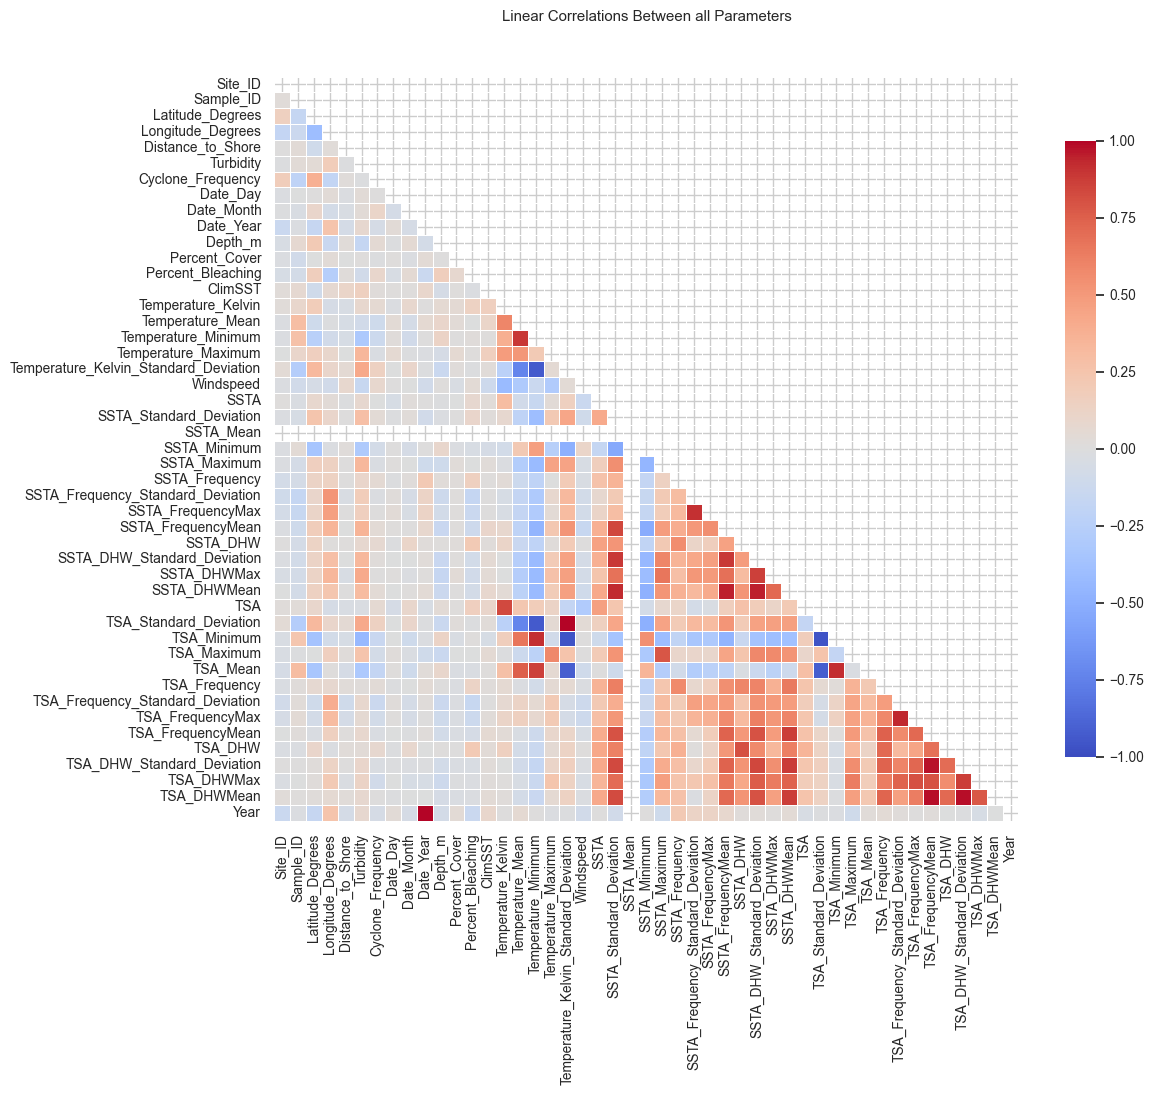

In [100]:
def Linear_Correlation(corr_matrix):
    # สร้าง mask เพื่อซ่อนครึ่งบน
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(12,10))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Linear Correlations Between all Parameters", pad=40)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.show()
    
Linear_Correlation(df_correlation.corr())

________________________________

## Preprocessing model

In [101]:
df_preprocessed = df_correlation.drop([
    'Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 
    'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 
    'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 
    'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'Year'],axis=1)

In [102]:
df_preprocessed.dtypes

Site_ID                                int64
Sample_ID                              int64
Latitude_Degrees                     float64
Longitude_Degrees                    float64
Distance_to_Shore                    float64
Turbidity                            float64
Cyclone_Frequency                    float64
Date_Day                               int64
Date_Month                             int64
Date_Year                              int64
Depth_m                              float64
Percent_Cover                        float64
Percent_Bleaching                    float64
ClimSST                              float64
Temperature_Kelvin                   float64
Temperature_Mean                     float64
Temperature_Maximum                  float64
Windspeed                            float64
SSTA                                 float64
SSTA_Standard_Deviation              float64
SSTA_Mean                            float64
SSTA_Minimum                         float64
SSTA_Maxim

In [103]:
df_preprocessed_model_want = df_preprocessed[df_wanteed_columns]
df_preprocessed_model_want

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
2,50.9,0.04,7.00,18.3690,-64.5640,298.79
5,51.0,0.27,11.50,9.8220,-75.8910,302.63
6,51.3,0.29,27.70,17.8110,-64.6300,301.19
8,51.4,0.35,4.05,25.4250,-80.1610,300.56
11,51.7,0.56,9.80,17.7670,-64.6210,301.24
...,...,...,...,...,...,...
41351,NaN,0.80,3.00,-6.1562,39.1223,299.79
41352,NaN,0.80,3.00,-6.1511,39.1266,299.79
41353,NaN,1.06,1.50,-3.2600,40.1500,300.44
41357,NaN,0.10,3.50,-8.3473,116.0503,301.01


## Drop NAN

In [104]:
df_model = df_preprocessed_model_want.dropna()

In [105]:
print(f"Data in model dataset: {len(df_model)}")

Data in model dataset: 19489


In [106]:
print(f"Data in cleaned dataset: {len(df_model)}")
print(f"Data in original dataset: {len(df)}")
print(f"Percentage dropped: {(len(df) - len(df_model)) / len(df) * 100:.2f}%")
print(f"Percentage df_model: {(len(df_model)) / len(df) * 100:.2f}%")

Data in cleaned dataset: 19489
Data in original dataset: 41361
Percentage dropped: 52.88%
Percentage df_model: 47.12%


In [107]:
nan_check(df_model)

,Total,%
Percent_Bleaching,0,0.0
SSTA,0,0.0
Depth_m,0,0.0
Latitude_Degrees,0,0.0
Longitude_Degrees,0,0.0
ClimSST,0,0.0


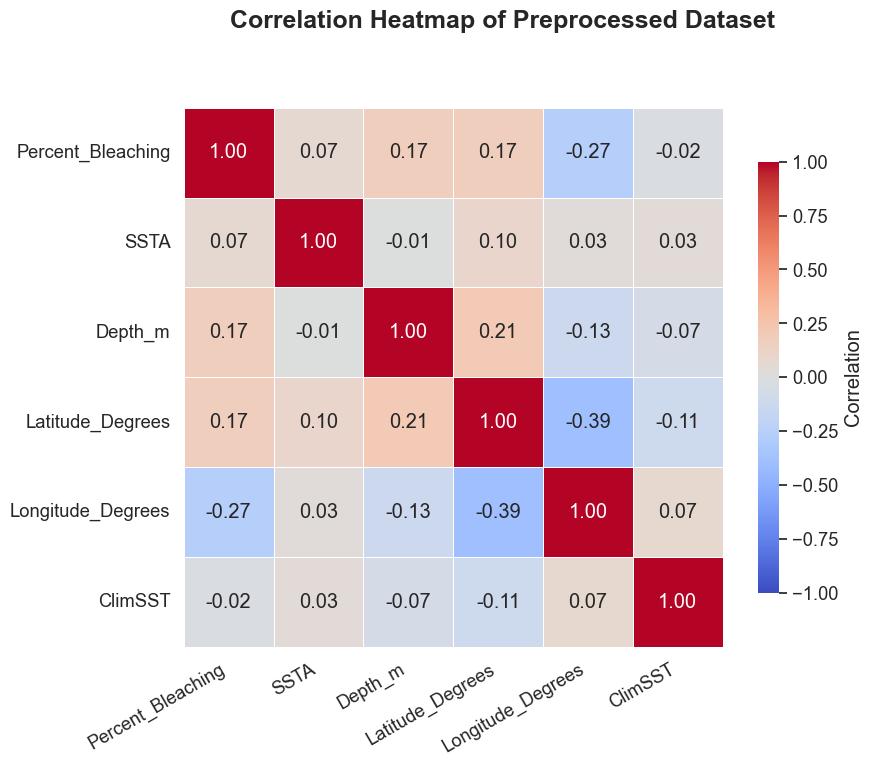

In [108]:
sns.set_theme(style="white", font_scale=1.2)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

corr = df_model[df_wanteed_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

fig.suptitle(
    "Correlation Heatmap of Preprocessed Dataset",
    fontsize=18,
    fontweight="bold",
    x=0.5,
    y=1.02,
    ha="center"
)


plt.show()

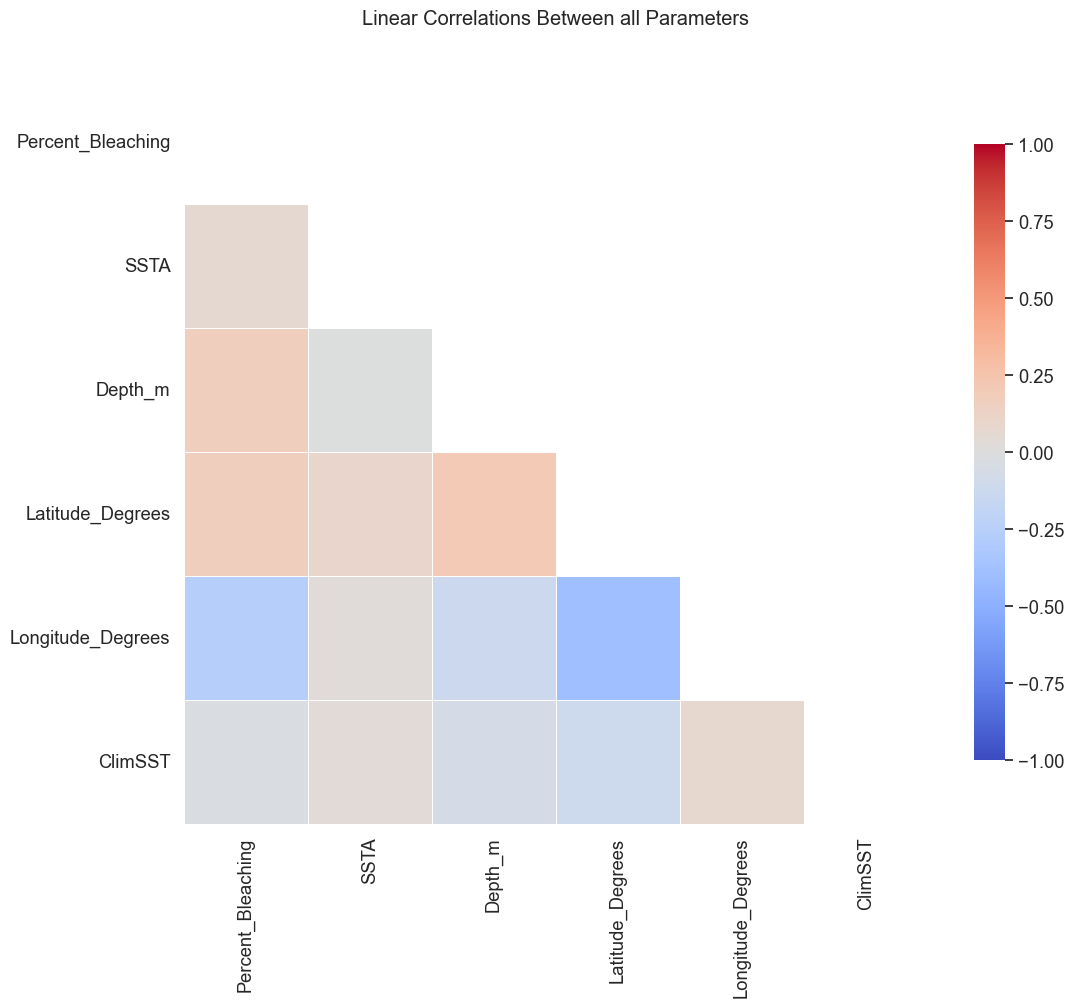

In [109]:
Linear_Correlation(df_model[df_wanteed_columns].corr())

##

## Objective is clustering zone 
- Hot climate zone
- else zone

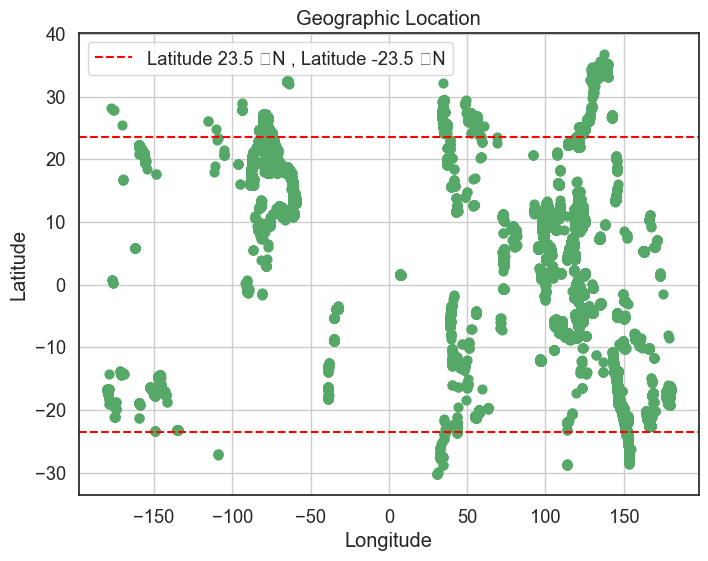

In [110]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Longitude_Degrees"],
    df["Latitude_Degrees"],
    color="g",
    s=40
)

plt.axhline(y=23.5, color='red', linestyle='--', label='Latitude 23.5 ํN , Latitude -23.5 ํN')
plt.axhline(y=-23.5, color='red', linestyle='--')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Location")
plt.legend()

plt.grid(True)

plt.show()

In [111]:
Zone_hot_climate = df_model[
    (df_model['Latitude_Degrees'] > -23.5) &
    (df_model['Latitude_Degrees'] < 23.5)
]

Zone_else = df_model[
    (df_model['Latitude_Degrees'] <= -23.5) | 
    (df_model['Latitude_Degrees'] >= 23.5)
]

print(f"zone hot climate: {len(Zone_hot_climate)}")
print(f"zone else: {len(Zone_else)}")


zone hot climate: 14678
zone else: 4811


In [112]:
Zone_hot_climate.describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,14678.000000,14678.000000,14678.000000,14678.000000,14678.000000,14678.000000
mean,8.337061,0.690901,7.100839,4.760857,39.406171,293.570108
std,19.669324,0.528987,4.262302,13.614089,104.232652,15.613662
min,0.000000,0.010000,0.000000,-23.460400,-179.859400,262.150000
25%,0.000000,0.290000,4.000000,-5.540600,-69.700000,298.790000
50%,0.000000,0.570000,6.000000,6.521000,102.997500,301.200000
75%,5.000000,0.990000,10.000000,17.777750,119.364200,302.110000
max,100.000000,4.610000,42.700000,23.484100,179.964500,304.390000


In [113]:
Zone_else.describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,4811.000000,4811.00000,4811.000000,4811.000000,4811.000000,4811.000000
mean,11.249435,0.87524,7.065136,22.061286,-5.695251,293.917849
std,17.961420,0.72044,4.208158,14.054486,90.119862,13.979258
min,0.000000,0.01000,0.000000,-28.162500,-93.830000,262.150000
25%,0.000000,0.37000,4.000000,24.582950,-80.349350,297.230000
50%,2.940000,0.72000,6.000000,25.208900,-79.307700,299.820000
75%,15.000000,1.17000,10.000000,26.297200,56.432200,301.155000
max,100.000000,5.90000,30.000000,35.744600,153.556900,307.040000


##

## Clustering

In [114]:
df_model_cluster = df_model.copy()

In [115]:
scaler = StandardScaler()

In [116]:
feature_cluster = df_model[['Latitude_Degrees' , 'Longitude_Degrees']]
Area = feature_cluster.copy()
Area_values = Area.values
X_scaled = scaler.fit_transform(Area_values)

feature_cluster_second = df_model[['SSTA', 'Percent_Bleaching']]
SSTA_Percent = feature_cluster_second.copy()
Area_values = SSTA_Percent.values
X_scaled_second = scaler.fit_transform(Area_values)

feature_cluster_third = df_model[['Latitude_Degrees', 'Percent_Bleaching']]
Latitude_Percent = feature_cluster_third.copy()
Area_values = Latitude_Percent.values
X_scaled_third = scaler.fit_transform(Area_values)

feature_cluster_fourth = df_model[['Latitude_Degrees', 'Depth_m']]
Latitude_Depth = feature_cluster_fourth.copy()
Area_values = Latitude_Depth.values
X_scaled_fourth = scaler.fit_transform(Area_values)

In [117]:
Area = feature_cluster[['Latitude_Degrees', 'Longitude_Degrees']]
Area_values = Area.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Area_values)

K = range(1, 10)

def The_Elbow_method(X_scaled):
    
    inertia_score = []
    # tring k values for n_clusters
    for k in K:
        kmeans = KMeans(n_clusters=k)
        labels = kmeans.fit_predict(X_scaled)
        score = kmeans.inertia_
        
        inertia_score.append(score)
        
        print(f"K_Value : {k} , score : {score}")
        
    return inertia_score

inertia_scores = The_Elbow_method(X_scaled)

K_Value : 1 , score : 38977.99999999999
K_Value : 2 , score : 17556.157710939635
K_Value : 3 , score : 10688.55011933727
K_Value : 4 , score : 5632.264837579976
K_Value : 5 , score : 3106.790247458018
K_Value : 6 , score : 2513.351197415837
K_Value : 7 , score : 2070.484318708243
K_Value : 8 , score : 1674.3206280803145
K_Value : 9 , score : 1243.8805343944834


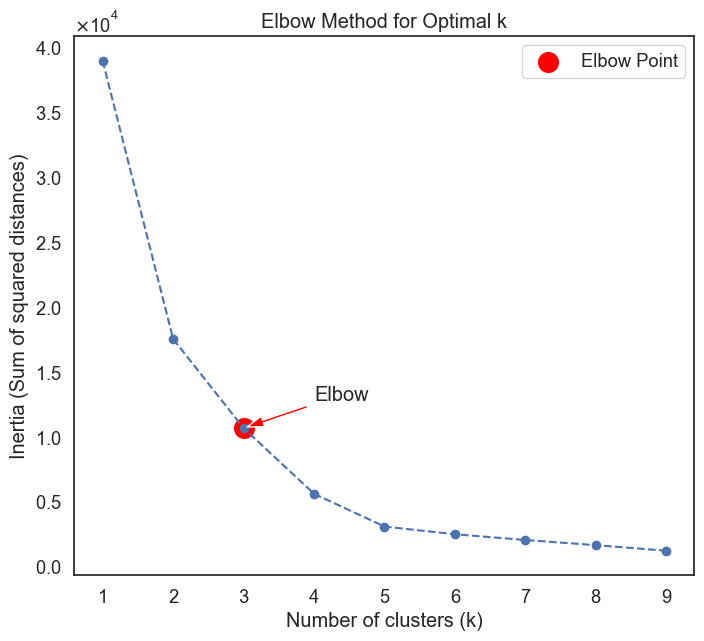

In [118]:
from matplotlib.ticker import ScalarFormatter

elbow_k = 3
elbow_y = inertia_scores[elbow_k - 1]

plt.figure(figsize=(8, 7))
plt.plot(range(1, 10), inertia_scores, marker='o', linestyle='--')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Sum of squared distances)")
plt.title("Elbow Method for Optimal k")

# วาดจุด elbow
plt.scatter(elbow_k, elbow_y, s=200, c='red', label='Elbow Point')
plt.annotate('Elbow',
             xy=(elbow_k, elbow_y),
             xytext=(elbow_k+1, elbow_y*1.2),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))

# เปลี่ยนแกน y ให้แสดงเป็นเลขยกกำลังทีละ tick
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend()
plt.show()

In [119]:
def K_means_clustering(df ,X_scaled, n_clusters):
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    
    labels = kmeans.fit_predict(X_scaled)
    
    return kmeans, labels

kmeans, labels = K_means_clustering(df_model_cluster, X_scaled, n_clusters=3)


In [120]:
np.unique(labels)

array([0, 1, 2])

In [121]:
df_model_cluster['cluster'] = kmeans.labels_
df_model_cluster.groupby('cluster')['Percent_Bleaching'].mean()

cluster
0     3.486134
1    15.789341
2     5.756581
Name: Percent_Bleaching, dtype: float64

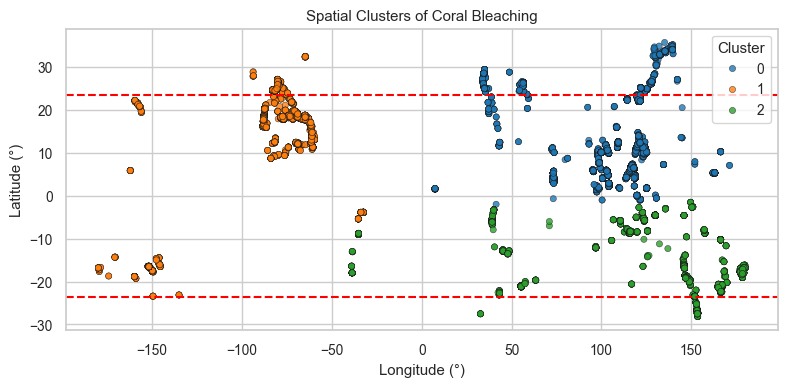

In [122]:
# สร้าง DataFrame สำหรับ cluster centers
centers_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Longitude_Degrees', 'Latitude_Degrees']
)
centers_df['cluster'] = range(len(centers_df))  # cluster index 0,1,2

# --------------------------------
# Plot spatial clusters
plt.figure(figsize=(8,4))
sns.set(style="whitegrid", font_scale=0.9)

# scatter plot: points colored by cluster
sns.scatterplot(
    data=df_model_cluster,
    x='Longitude_Degrees',
    y='Latitude_Degrees',
    hue='cluster',
    palette='tab10',
    s=20,
    alpha=0.8,
    edgecolor='k'
)

plt.axhline(y=23.5, color='red', linestyle='--')
plt.axhline(y=-23.5, color='red', linestyle='--')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Location")
plt.legend()


plt.title('Spatial Clusters of Coral Bleaching')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

In [123]:
df_model_cluster[df_model_cluster.cluster == 0].describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST,cluster
count,7754.000000,7754.000000,7754.000000,7754.000000,7754.000000,7754.000000,7754.0
mean,3.486134,0.777711,6.712671,12.823730,102.045435,294.642831,0.0
std,12.662915,0.586476,3.071672,9.504141,29.992201,14.967961,0.0
min,0.000000,0.010000,0.000000,-1.986000,7.336900,262.150000,0.0
25%,0.000000,0.320000,4.700000,4.819500,99.840500,298.510000,0.0
50%,0.000000,0.650000,6.000000,10.066900,114.319150,301.760000,0.0
75%,0.500000,1.100000,10.000000,22.550600,120.711900,302.430000,0.0
max,100.000000,4.230000,30.000000,35.744600,171.266600,307.040000,0.0


In [124]:
df_model_cluster[df_model_cluster.cluster == 1].describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST,cluster
count,8164.000000,8164.000000,8164.000000,8164.000000,8164.000000,8164.000000,8164.0
mean,15.789341,0.717291,8.002093,16.062417,-85.976169,292.374794,1.0
std,23.375770,0.607118,5.248821,12.369801,26.152653,16.094030,0.0
min,0.000000,0.010000,0.000000,-23.422000,-179.859400,262.150000,1.0
25%,0.000000,0.300000,4.000000,16.199900,-87.464800,298.810000,1.0
50%,5.500000,0.580000,7.000000,18.667200,-80.280150,300.460000,1.0
75%,21.600000,0.990000,10.700000,24.581075,-73.526450,301.640000,1.0
max,100.000000,5.900000,42.700000,32.510000,-32.422700,303.660000,1.0


In [125]:
df_model_cluster[df_model_cluster.cluster == 2].describe()

,Percent_Bleaching,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST,cluster
count,3571.000000,3571.00000,3571.000000,3571.000000,3571.000000,3571.000000,3571.0
mean,5.756581,0.69042,5.835158,-15.276413,129.278372,294.442030,2.0
std,15.943997,0.53647,3.358257,7.109267,47.750669,13.430578,0.0
min,0.000000,0.01000,0.100000,-28.162500,-38.988200,262.150000,2.0
25%,0.000000,0.28000,3.000000,-21.026100,115.910100,297.555000,2.0
50%,0.000000,0.57000,5.000000,-16.812300,146.557000,299.630000,2.0
75%,2.250000,0.97000,8.000000,-8.357900,164.762500,301.290000,2.0
max,100.000000,4.61000,21.700000,-1.523600,179.964500,304.110000,2.0


In [126]:
kmeans, labels = K_means_clustering(df_model_cluster, X_scaled_second, n_clusters=3)

In [127]:
df_model_cluster['cluster_second'] = kmeans.labels_
np.unique(df_model_cluster['cluster_second'])

array([0, 1, 2])

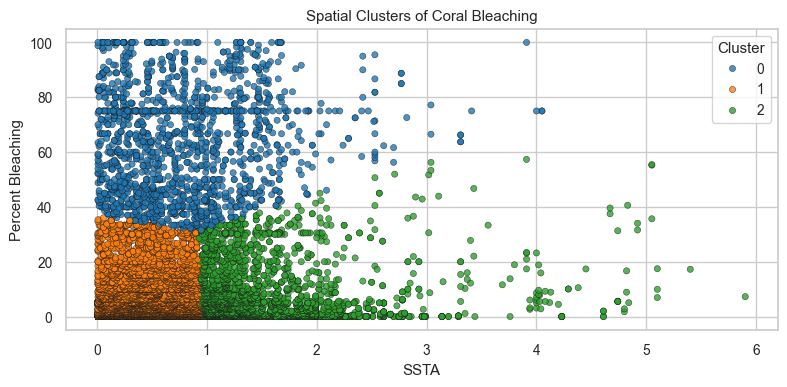

In [128]:
# Plot spatial clusters
plt.figure(figsize=(8,4))
sns.set(style="whitegrid", font_scale=0.9)

# scatter plot: points colored by cluster
sns.scatterplot(
    data=df_model_cluster,
    x='SSTA',
    y='Percent_Bleaching',
    hue='cluster_second',
    palette='tab10',
    s=20,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Spatial Clusters of Coral Bleaching')
plt.xlabel('SSTA')
plt.ylabel('Percent Bleaching')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

In [129]:
kmeans, labels = K_means_clustering(df_model_cluster, X_scaled_third, n_clusters=3)

In [130]:
df_model_cluster['cluster_third'] = kmeans.labels_
np.unique(df_model_cluster['cluster_third'])

array([0, 1, 2])

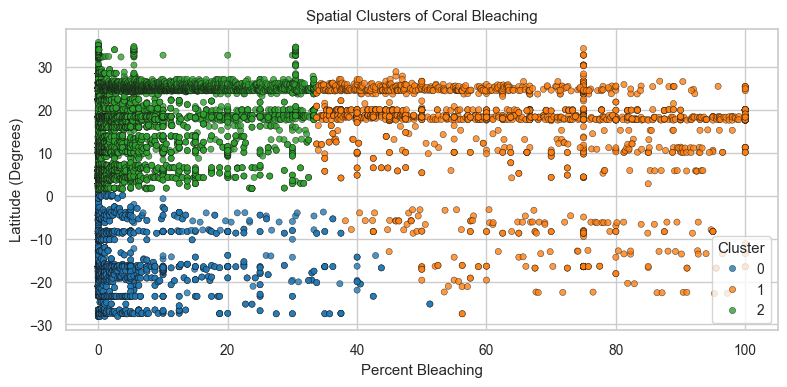

In [131]:
# Plot spatial clusters
plt.figure(figsize=(8,4))
sns.set(style="whitegrid", font_scale=0.9)

# scatter plot: points colored by cluster
sns.scatterplot(
    data=df_model_cluster,
    x='Percent_Bleaching',
    y='Latitude_Degrees',
    hue='cluster_third',
    palette='tab10',
    s=20,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Spatial Clusters of Coral Bleaching')
plt.xlabel('Percent Bleaching')
plt.ylabel('Latitude (Degrees)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

In [132]:
kmeans, labels = K_means_clustering(df_model_cluster, X_scaled_fourth, n_clusters=3)

In [133]:
df_model_cluster['cluster_fourth'] = kmeans.labels_
np.unique(df_model_cluster['cluster_fourth'])

array([0, 1, 2])

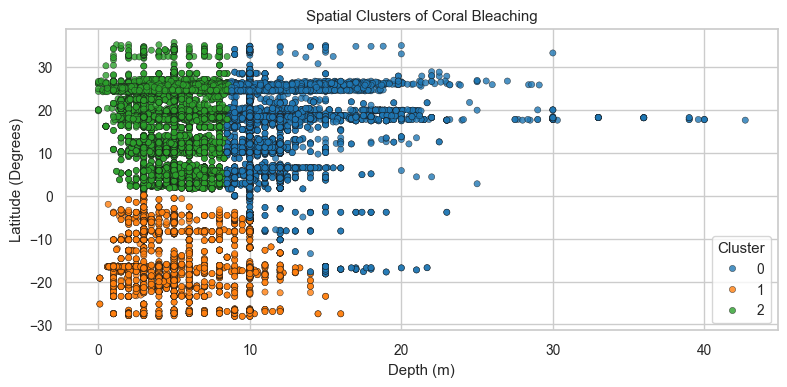

In [134]:
# Plot spatial clusters
plt.figure(figsize=(8,4))
sns.set(style="whitegrid", font_scale=0.9)

# scatter plot: points colored by cluster
sns.scatterplot(
    data=df_model_cluster,
    x='Depth_m',
    y='Latitude_Degrees',
    hue='cluster_fourth',
    palette='tab10',
    s=20,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Spatial Clusters of Coral Bleaching')
plt.xlabel('Depth (m)')
plt.ylabel('Latitude (Degrees)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

____________________________________________________________

## Randomforest (RF)

In [ ]:
RF_feature = df_model[['Latitude_Degrees', 'Longitude_Degrees', 'SSTA', 'Depth_m', 'ClimSST']]
RF_target = df_model[['Percent_Bleaching']]

RF_feature_values = RF_feature.values
RF_target_values = RF_target.values

In [136]:
# Step 1: แบ่งข้อมูลออกเป็น train + validation และ test
X_temp, X_test, y_temp, y_test = train_test_split(
    RF_feature_values, RF_target_values, test_size=0.3, random_state=42
)

# Step 2: แบ่ง X_temp ออกเป็น train และ validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42  # 0.2 ของ 70% จะได้ validation ~14% ของทั้งหมด
)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((10913, 5), (10913, 1), (2729, 5), (2729, 1), (5847, 5), (5847, 1))

In [137]:
X_temp.shape, y_temp.shape, X_test.shape, y_test.shape

((13642, 5), (13642, 1), (5847, 5), (5847, 1))

In [138]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((10913, 5), (10913, 1), (5847, 5), (5847, 1))

In [139]:
# with best parameters for 300 estimators
seed = 42
forest = RandomForestRegressor(
    max_features='sqrt',
    max_depth=16,
    criterion='squared_error',
    bootstrap=False,
    n_estimators=300,
    random_state=42
)

forest.fit(X_temp, y_temp)


RandomForestRegressor(bootstrap=False, max_depth=16, max_features='sqrt',
                      n_estimators=300, random_state=42)

In [142]:
y_test_pred = forest.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
print("Test MSE:", test_mse.round(2))


test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse.round(2))

test_r2 = r2_score(y_test, y_test_pred)
print("Test R2 Score:", test_r2.round(2))

test_mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Absolute Error:", test_mae.round(2))

Test MSE: 121.52
Test RMSE: 11.02
Test R2 Score: 0.66
Mean Absolute Error: 5.07
